In [1]:
# --- Cell 1: Setup ---
import re
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.ndimage import minimum_filter1d, gaussian_filter1d

# %matplotlib widget



def set_axes_equal(ax, pts):
    """ Ensure 3D plots are perfectly cubic/isotropic. """
    x, y, z = pts[:,0], pts[:,1], pts[:,2]
    max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max() / 2.0
    mid_x, mid_y, mid_z = (x.max()+x.min())*0.5, (y.max()+y.min())*0.5, (z.max()+z.min())*0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [2]:
# --- Cell 2: Load Data ---
INPUT = 'local_bonds_v6_outputs'

EXPECTED_D_NN = 45.5 # Nearest neighbor spacing for FCC
EXPECTED_A = EXPECTED_D_NN * np.sqrt(2.0)  # Lattice parameter 'a'

def parse_vector_value(x):
    """Robust parser for messy string arrays in the CSV."""
    if isinstance(x, (list, np.ndarray)): return np.array(x, dtype=float)
    if isinstance(x, str):
        x = x.strip()
        if ',' in x:
            try: return np.array(ast.literal_eval(x), dtype=float)
            except: pass
        clean_s = x.replace('[', '').replace(']', '').strip()
        try: return np.fromstring(clean_s, sep=' ')
        except: pass
    return np.array([np.nan, np.nan, np.nan])

# 1. Load the strictly "kept" assignments to avoid padding
df_ft = pd.read_csv(f'{INPUT}/pid65_oid11_kept_assignments.csv')

# 2. Extract arrays
R_eq = np.vstack(df_ft['predicted_point'].apply(parse_vector_value).values)
R_act = np.vstack(df_ft['matched_point'].apply(parse_vector_value).values)
ijk = np.vstack(df_ft['global_ijk_round'].apply(parse_vector_value).values)

U_vec = R_act - R_eq  

# Center the equilibrium lattice
center_mass = np.mean(R_eq, axis=0)
R_eq_centered = R_eq - center_mass

print(f"Data Loaded: {len(R_eq)} valid particles.")

Data Loaded: 534 valid particles.


In [3]:
# --- Cell 3: Basis Fit & Grid Generation ---

# 1. Origin-Corrected Least Squares for Exact Experimental Basis
ones_column = np.ones((len(ijk), 1))
ijk_with_intercept = np.hstack((ijk, ones_column))
solution, _, _, _ = np.linalg.lstsq(ijk_with_intercept, R_eq, rcond=None)

# M replaces your 'fcc_vectors_best'
M = solution[0:3, :]  # Rows are Cartesian primitive vectors
A = M.T               # Columns are basis vectors (for tensor math)
A_inv = np.linalg.inv(A)

# Calculate Metric Tensors for later projections
g_ij = A.T @ A                
g_up_ij = np.linalg.inv(g_ij) 

Recip_Basis = 2.0 * np.pi * np.linalg.inv(M).T

# 2. --- Grid 1: The "Fundamental" Grid (M approx N) ---
L_dims = R_eq.max(axis=0) - R_eq.min(axis=0)
L_max = L_dims.max()
n_cells_approx = int(np.round(L_max / np.linalg.norm(M[:,0]))) 
N_fundamental = max(n_cells_approx, 3) 

print(f"Cluster Size: ~{n_cells_approx} lattice constants wide.")
print(f"Generating Fundamental Grid with {N_fundamental}^3 points.")

h_fund = np.linspace(-0.5, 0.5, N_fundamental)
H1f, H2f, H3f = np.meshgrid(h_fund, h_fund, h_fund, indexing='ij')
H_flat_fund = np.stack([H1f.ravel(), H2f.ravel(), H3f.ravel()], axis=1)
Q_fund = H_flat_fund @ Recip_Basis

# 3. --- Grid 2: The "Oversampled" Grid (M >> N) ---
N_highres = 15 
print(f"Generating High-Res Grid with {N_highres}^3 points.")

h_hr = np.linspace(-0.5, 0.5, N_highres)
H1h, H2h, H3h = np.meshgrid(h_hr, h_hr, h_hr, indexing='ij')
H_flat_hr = np.stack([H1h.ravel(), H2h.ravel(), H3h.ravel()], axis=1)
Q_highres = H_flat_hr @ Recip_Basis

print(f"Done. Fundamental Points: {len(Q_fund)} | High-Res Points: {len(Q_highres)}")

experimental_d_nn = np.mean(np.linalg.norm(M, axis=1))
error_pct = 100 * abs(experimental_d_nn - EXPECTED_D_NN) / EXPECTED_D_NN

print(f"Experimental NN Spacing: {experimental_d_nn:.2f}")
print(f"Theoretical NN Spacing:  {EXPECTED_D_NN:.2f}")
print(f"Lattice Calibration Error: {error_pct:.2f}%")

Cluster Size: ~7 lattice constants wide.
Generating Fundamental Grid with 7^3 points.
Generating High-Res Grid with 15^3 points.
Done. Fundamental Points: 343 | High-Res Points: 3375
Experimental NN Spacing: 45.03
Theoretical NN Spacing:  45.50
Lattice Calibration Error: 1.04%


In [4]:
# --- Cell 4: NUDFT & Decomposition ---

def compute_vector_nudft(r_pos, u_vec, q_vecs):
    phase = q_vecs @ r_pos.T
    factors = np.exp(-1j * phase)
    return factors @ u_vec

print("Computing NUDFT on High-Res Grid (M >> N)...")
U_k_hr_cart = compute_vector_nudft(R_eq_centered, U_vec, Q_highres)

# --- TENSOR PROJECTIONS (High-Res Grid) ---
# 1. Convert Cartesian Q and U to their Primitive Tensor Components
Q_vecs_cov = (A.T @ Q_highres.T).T  # Covariant Q
U_vecs_con = (A_inv @ U_k_hr_cart.T).T   # Contravariant U

# 2. True Magnitude of Q using reciprocal metric tensor g^{ij}
Q_mag_sq = np.einsum('ij, ni, nj -> n', g_up_ij, Q_vecs_cov, Q_vecs_cov)
Q_mag = np.sqrt(Q_mag_sq)

# 3. Covariant direction vector (\hat{q}_i)
with np.errstate(divide='ignore', invalid='ignore'):
    Q_hat_cov = Q_vecs_cov / Q_mag[:, None]
Q_hat_cov[np.isnan(Q_hat_cov)] = 0.0

# 4. Longitudinal Fluctuation (Projection)
U_L_scalar = np.einsum('ni, ni -> n', Q_hat_cov, U_vecs_con)
S_L = np.abs(U_L_scalar)**2

# 5. Total Fluctuation (Trace using real-space metric tensor g_{ij})
S_Total = np.einsum('ij, ni, nj -> n', g_ij, U_vecs_con, np.conj(U_vecs_con)).real

# 6. Transverse Fluctuation
S_T = S_Total - S_L

print(f"Complete. Max Power (HR Total): {S_Total.max():.2e}")

Computing NUDFT on High-Res Grid (M >> N)...
Complete. Max Power (HR Total): 7.09e+05


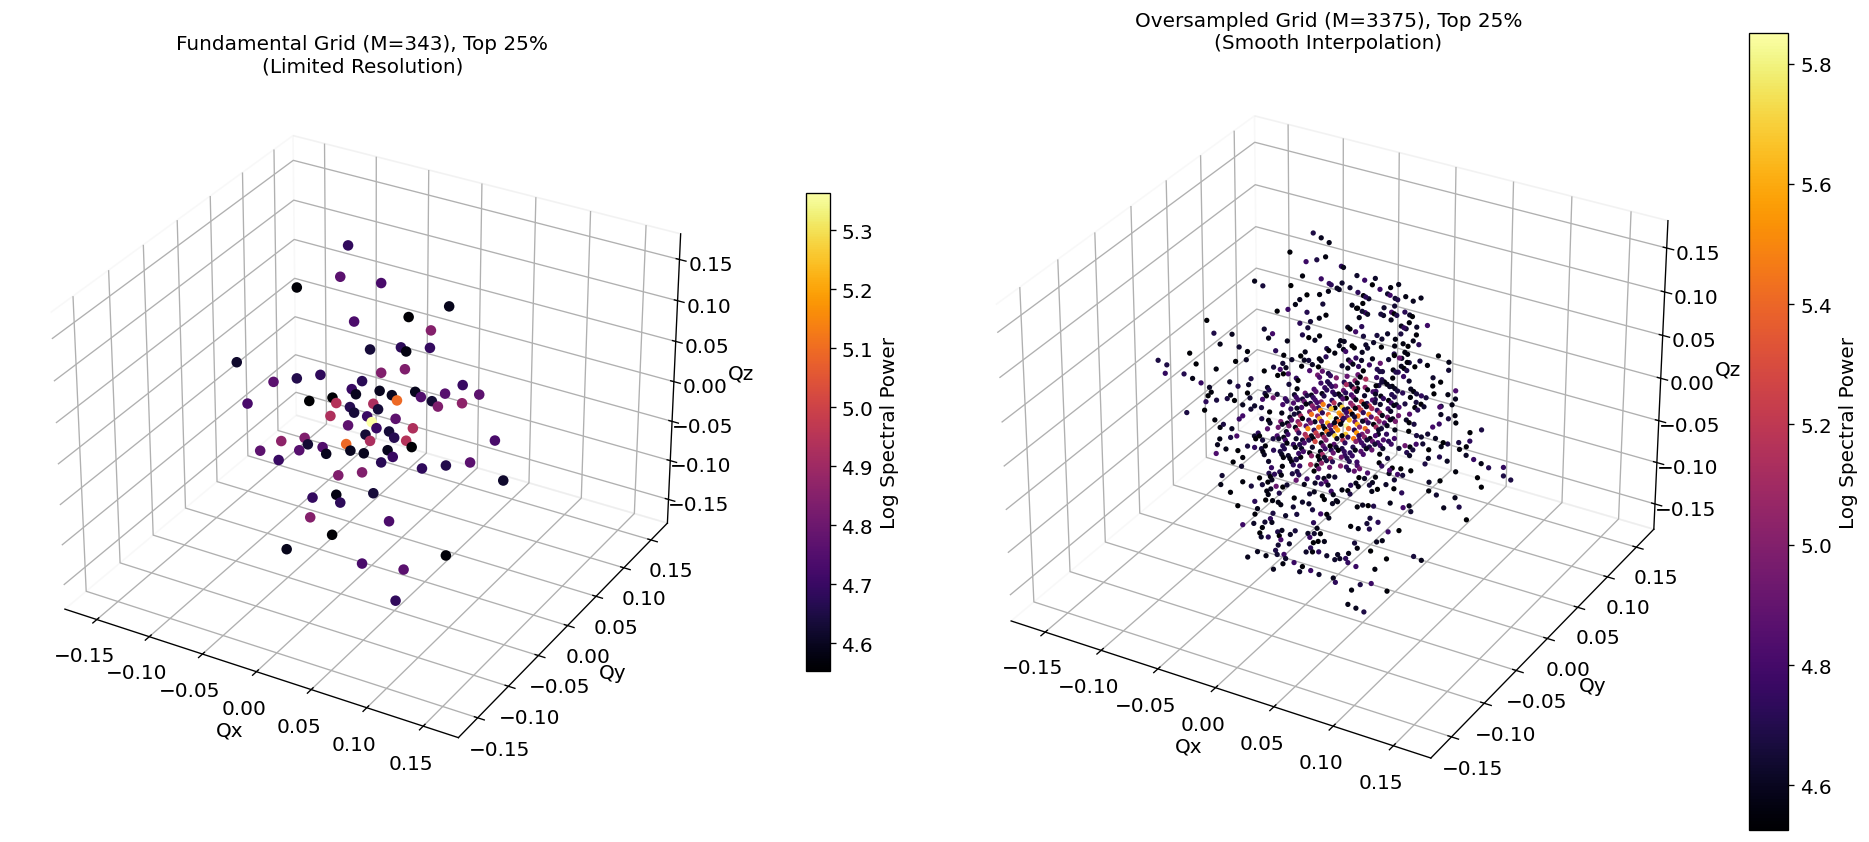

In [5]:
# --- Cell 4a: Comparison of Sampling Density (Log Scale) ---

# Compute the Fundamental Grid projections
U_k_fund_cart = compute_vector_nudft(R_eq_centered, U_vec, Q_fund)
U_vecs_con_fund = (A_inv @ U_k_fund_cart.T).T
S_Total_fund = np.einsum('ij, ni, nj -> n', g_ij, U_vecs_con_fund, np.conj(U_vecs_con_fund)).real

# ==========================================
# 1. Setup Figure
# ==========================================
fig = plt.figure(figsize=(16, 7))

# --- Plot 1: Fundamental Grid (The "Raw Information") ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Filter for visibility (Top 25%)
thresh_fund = np.percentile(S_Total_fund, 75)
mask_fund = S_Total_fund > thresh_fund

log_S_fund = np.log10(S_Total_fund[mask_fund] + 1e-12)

p1 = ax1.scatter(Q_fund[mask_fund, 0], Q_fund[mask_fund, 1], Q_fund[mask_fund, 2],
                 c=log_S_fund, cmap='inferno', s=40, alpha=1.0, edgecolors='none')

ax1.set_title(f"Fundamental Grid (M={len(Q_fund)}), Top 25%\n(Limited Resolution)", fontsize=12)
ax1.set_xlabel('Qx')
ax1.set_ylabel('Qy')
ax1.set_zlabel('Qz')

# Make panes transparent for cleaner look
ax1.xaxis.pane.fill = ax1.yaxis.pane.fill = ax1.zaxis.pane.fill = False

cbar1 = fig.colorbar(p1, ax=ax1, shrink=0.6, pad=0.1)
cbar1.set_label('Log Spectral Power')

# --- Plot 2: High-Res Grid (The "Smooth Field") ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Filter for visibility (Top 5% - strictly peaks)
thresh_hr = np.percentile(S_Total, 75)
mask_hr = S_Total > thresh_hr

log_S_hr = np.log10(S_Total[mask_hr] + 1e-12)

p2 = ax2.scatter(Q_highres[mask_hr, 0], Q_highres[mask_hr, 1], Q_highres[mask_hr, 2],
                 c=log_S_hr, cmap='inferno', s=10, alpha=1.0, edgecolors='none')

ax2.set_title(f"Oversampled Grid (M={len(Q_highres)}), Top 25%\n(Smooth Interpolation)", fontsize=12)
ax2.set_xlabel('Qx')
ax2.set_ylabel('Qy')
ax2.set_zlabel('Qz')

ax2.xaxis.pane.fill = ax2.yaxis.pane.fill = ax2.zaxis.pane.fill = False

cbar2 = fig.colorbar(p2, ax=ax2)
cbar2.set_label('Log Spectral Power')

# Apply equal aspect ratio to prevent stretching
set_axes_equal(ax1, Q_highres)
set_axes_equal(ax2, Q_highres)

plt.tight_layout()

plt.savefig("Grid Comparison.svg", format="svg", bbox_inches="tight")
plt.show()

Method: Shell Binning (Decimals=3)
Data Condensed: 3375 raw wavevectors -> 157 smoothed points.


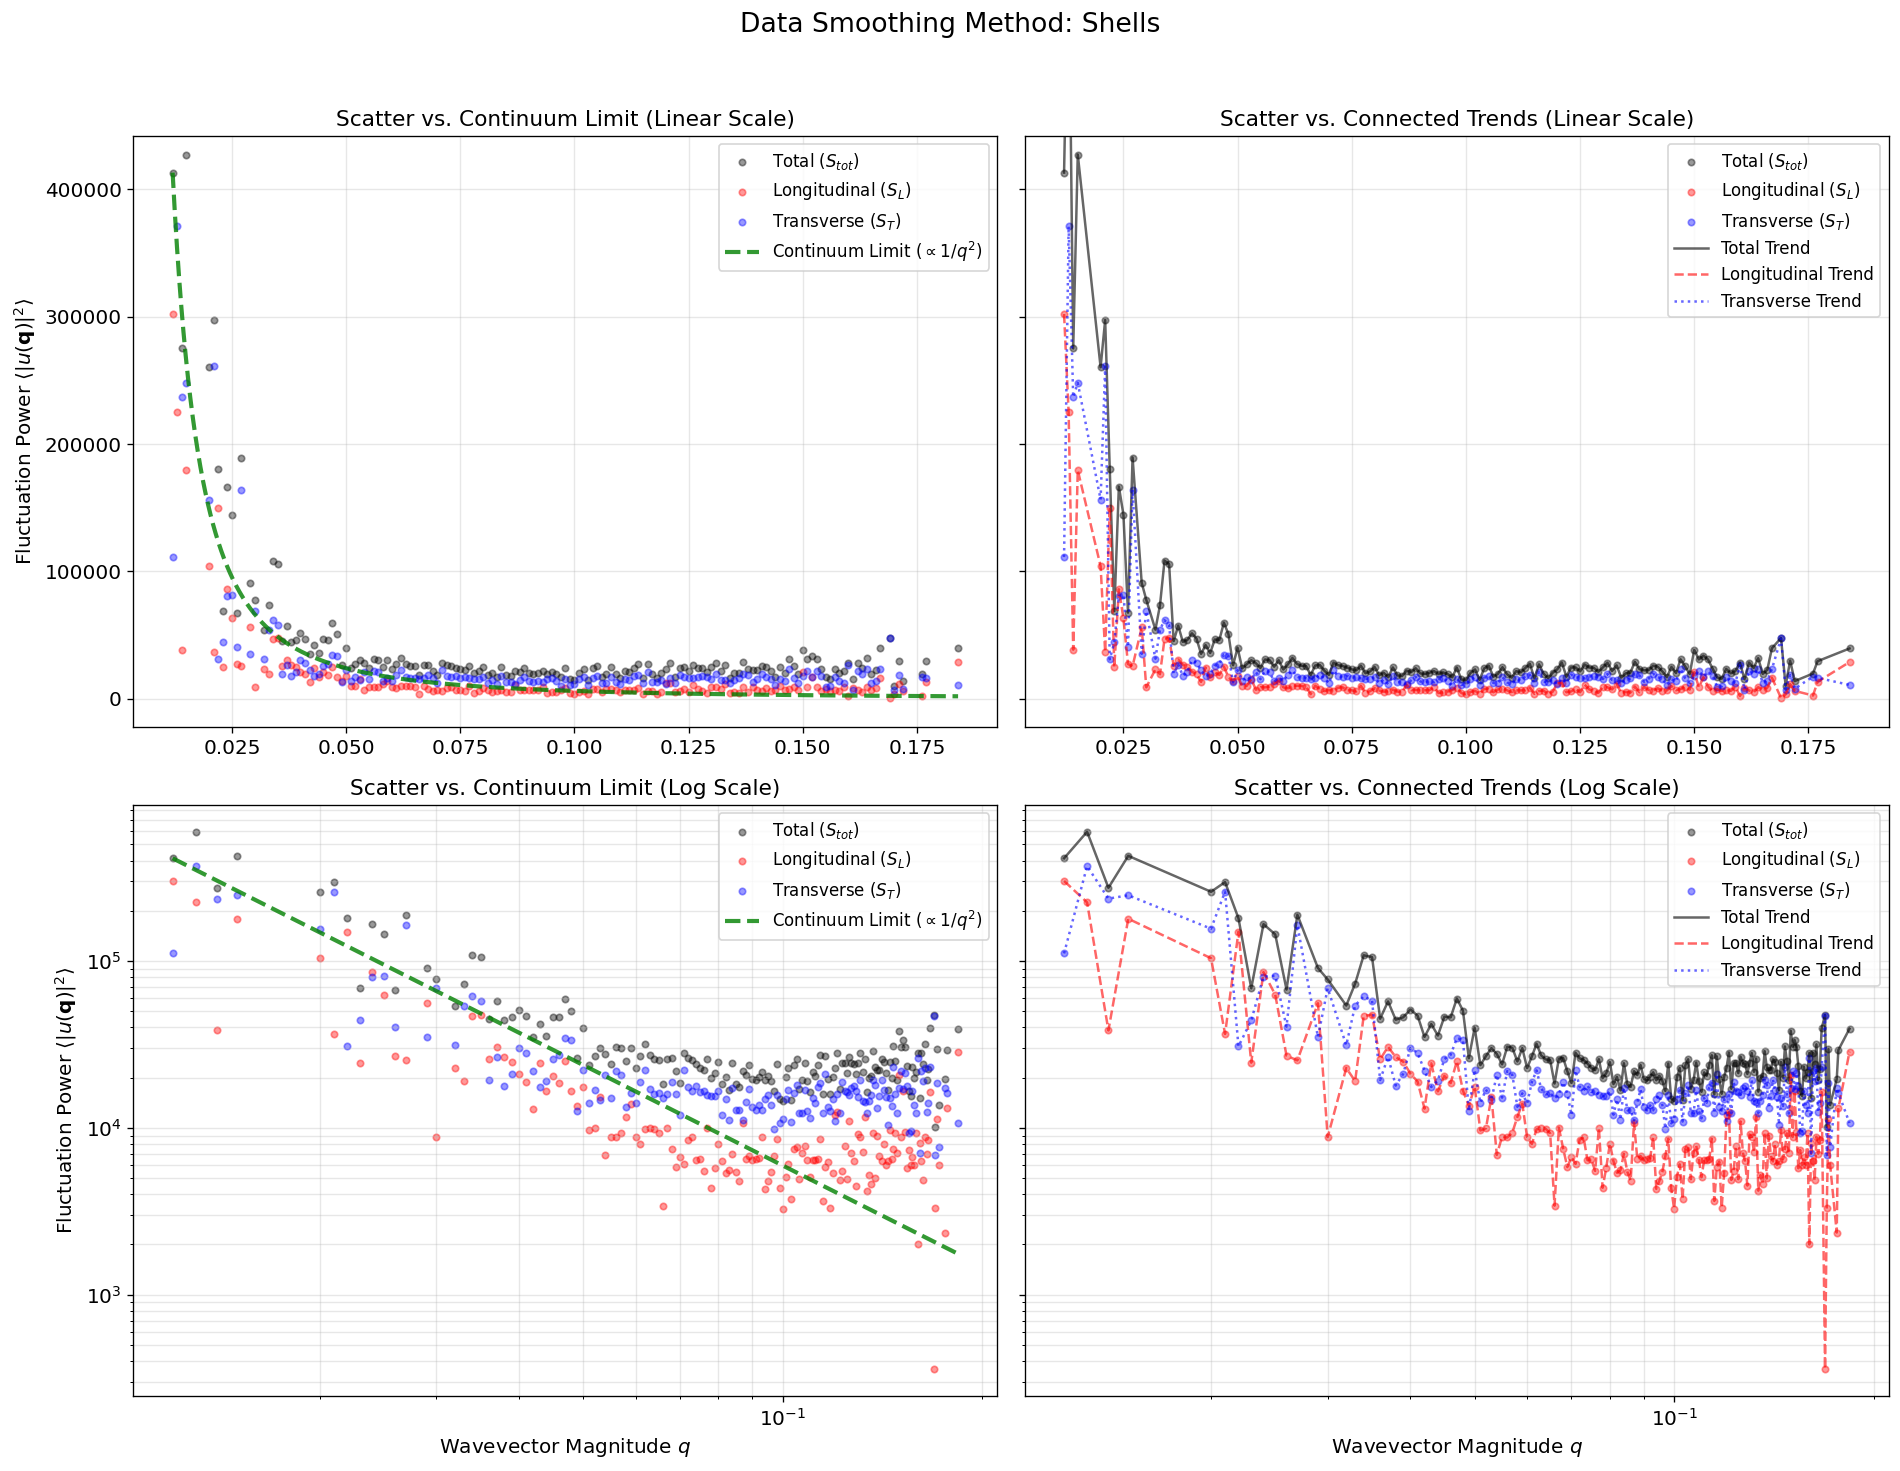

Global Maximum Fluctuation Power at q = 0.0130


In [6]:
# --- Cell 5: Raw Data Smoothing & 2x2 Visualization ---

# ==========================================
# 0. CONFIGURATION: Choose your smoothing method
# ==========================================
SMOOTHING_METHOD = 'shells'  # Options: 'shells' or 'sliding_window'

# Parameters for 'shells' method
SHELL_DECIMALS = 3  

# Parameters for 'sliding_window' method
# (Number of raw points to average together. Increase for more smoothing)
WINDOW_SIZE = 500

# ==========================================
# 1. Process Data
# ==========================================
# Create a dataframe of the raw, unbinned data and sort it strictly by q
df_raw = pd.DataFrame({
    'q': Q_mag,
    'S_tot': S_Total,
    'S_L': S_L,
    'S_T': S_T
}).sort_values('q').reset_index(drop=True)

if SMOOTHING_METHOD == 'shells':
    # Method A: Round to nearest decimal and average identical bins
    df_raw['q_round'] = np.round(df_raw['q'], SHELL_DECIMALS)
    df_smoothed = df_raw.groupby('q_round').mean().reset_index()
    df_smoothed = df_smoothed.drop(columns=['q']).rename(columns={'q_round': 'q'})
    print(f"Method: Shell Binning (Decimals={SHELL_DECIMALS})")

elif SMOOTHING_METHOD == 'sliding_window':
    # Method B: Continuous rolling average over the sorted data
    df_smoothed = df_raw.rolling(window=WINDOW_SIZE, center=True).mean().dropna()
    
    # Optional: Downsample slightly for plotting performance if dataset is massive
    # df_smoothed = df_smoothed.iloc[::10] 
    print(f"Method: Sliding Window Average (Window Size={WINDOW_SIZE} points)")

else:
    raise ValueError("Invalid SMOOTHING_METHOD selected.")

# Filter out the pure DC translation component (q very close to 0)
df_smoothed = df_smoothed[df_smoothed['q'] > 0.005].reset_index(drop=True)

print(f"Data Condensed: {len(Q_mag)} raw wavevectors -> {len(df_smoothed)} smoothed points.")

# ==========================================
# 2. Extract arrays for plotting
# ==========================================
q_vals = df_smoothed['q'].values
y_tot = df_smoothed['S_tot'].values
y_L = df_smoothed['S_L'].values
y_T = df_smoothed['S_T'].values

# Calculate the 1/q^2 reference line (Using geomspace for smooth log plotting)
q_ref = np.geomspace(q_vals.min(), q_vals.max(), 500)
y_ref = y_tot[0] * (q_vals[0]**2) * (q_ref**-2)

# ==========================================
# 3. Plotting (2x2 Grid: Rows=Scale, Cols=Style)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey='row', sharex='row')

for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        
        # Everyone gets the scatter points
        ax.scatter(q_vals, y_tot, color='black', s=15, alpha=0.4, label='Total ($S_{tot}$)')
        ax.scatter(q_vals, y_L, color='red', s=15, alpha=0.4, label='Longitudinal ($S_L$)')
        ax.scatter(q_vals, y_T, color='blue', s=15, alpha=0.4, label='Transverse ($S_T$)')
        
        # Left Column: Add the Green Continuum Limit
        if col == 0:
            ax.plot(q_ref, y_ref, 'g--', linewidth=2.5, alpha=0.8, label=r'Continuum Limit ($\propto 1/q^{2}$)')
            title_base = "Scatter vs. Continuum Limit"
        
        # Right Column: Add the Connecting Trend Lines
        else:
            ax.plot(q_vals, y_tot, 'k-', alpha=0.6, linewidth=1.5, label='Total Trend')
            ax.plot(q_vals, y_L, 'r--', alpha=0.6, linewidth=1.5, label='Longitudinal Trend')
            ax.plot(q_vals, y_T, 'b:', alpha=0.6, linewidth=1.5, label='Transverse Trend')
            title_base = "Scatter vs. Connected Trends"

        # Top Row: Keep Linear
        if row == 0:
            ax.set_title(f"{title_base} (Linear Scale)", fontsize=13)
            if col == 0:
                y_max_vis = np.percentile(y_tot, 98) * 1.5 
                ax.set_ylim(-0.05 * y_max_vis, y_max_vis)
        
        # Bottom Row: Set to Log Scale
        else:
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_title(f"{title_base} (Log Scale)", fontsize=13)
            
        # Standard Formatting
        if col == 0:
            ax.set_ylabel(r"Fluctuation Power $\langle |u(\mathbf{q})|^2 \rangle$", fontsize=12)
        
        if row == 1:
            ax.set_xlabel('Wavevector Magnitude $q$', fontsize=12)
            
        ax.grid(True, which='both', alpha=0.3)
        ax.legend(loc='upper right', fontsize=10)

plt.suptitle(f"Data Smoothing Method: {SMOOTHING_METHOD.replace('_', ' ').title()}", fontsize=16, y=1.02)
plt.tight_layout()

plt.savefig("Smoothing - Comparison.svg", format="svg", bbox_inches="tight")
plt.show()

# Print statistics based on the processed spectrum
peak_idx = np.argmax(y_tot)
print(f"Global Maximum Fluctuation Power at q = {q_vals[peak_idx]:.4f}")

# Rename df_smoothed to df_shells at the very end so that Cells 9, 10, and 11 don't break!
df_shells = df_smoothed

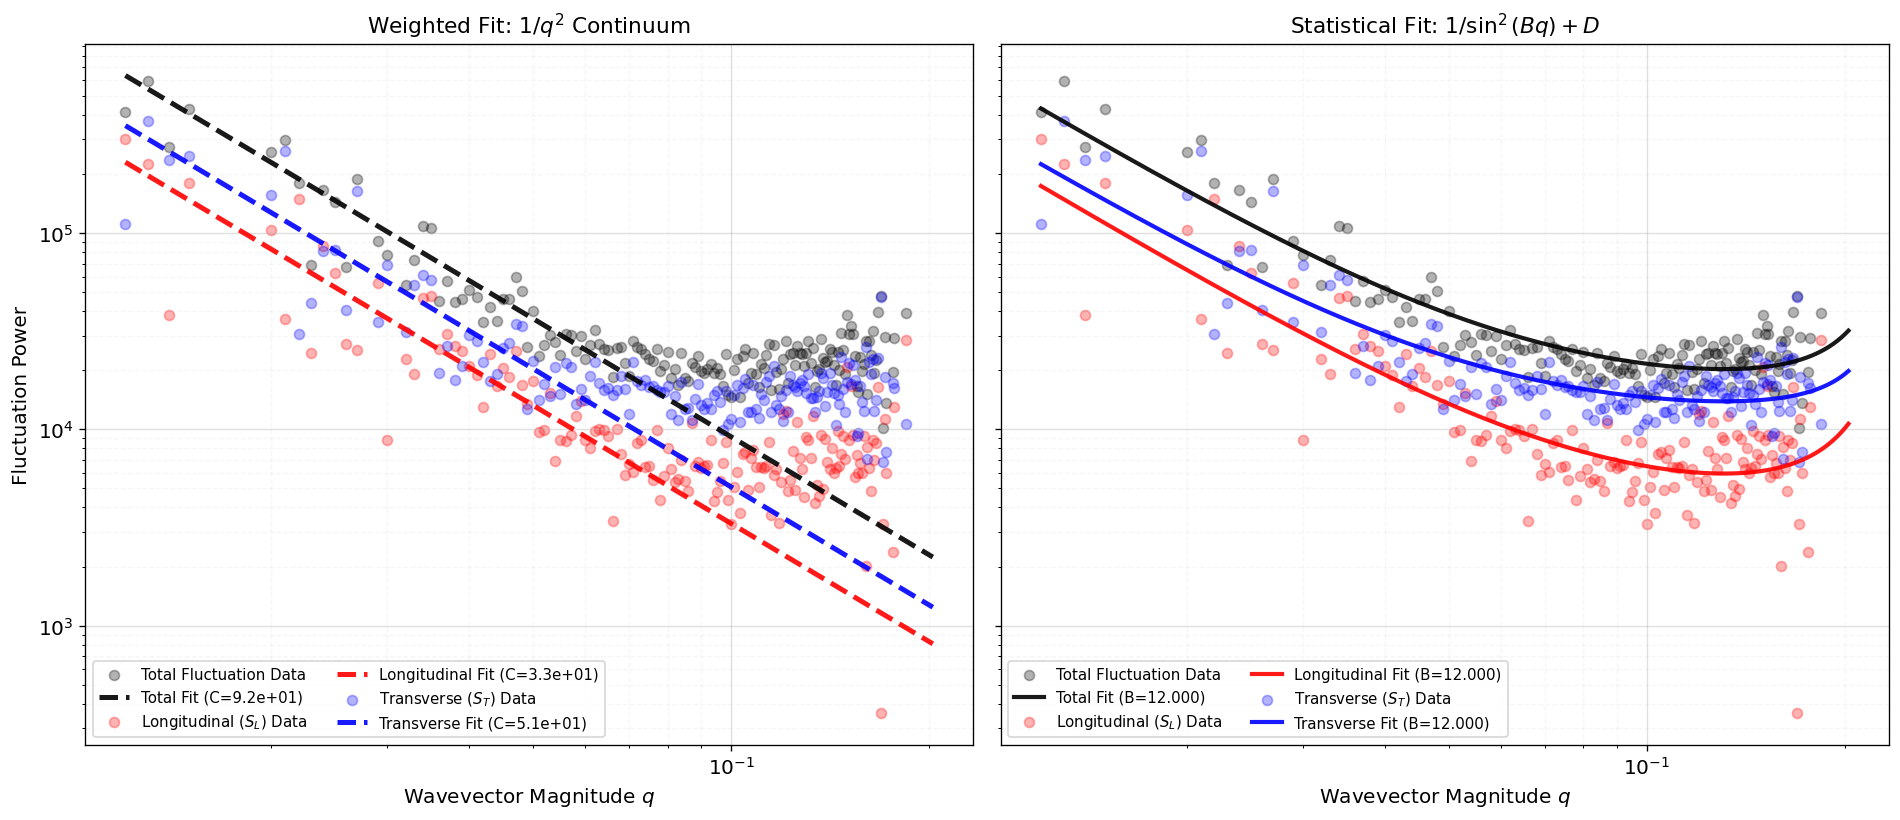

In [8]:
# --- Cell 6a: Overlay Log-Log Visualization (Continuum vs. Lattice Fit) ---

# ==========================================
# 1. DEFINE MATHEMATICAL MODELS
# ==========================================
def math_continuum_model(q, C):
    return C / (q**2)

def log_model_cont_fit(lq, lC):
    q = 10**lq
    C = 10**lC
    y = math_continuum_model(q, C)
    return np.log10(np.clip(y, 1e-8, np.inf))

def math_lattice_model(q, C, B, D):
    B = max(B, 1e-6) # Prevent exact zero division
    return C * (B**2) / (np.sin(B * q)**2) + D

def log_model_latt_fit(lq, lC, B, lD):
    q = 10**lq
    C = 10**lC
    D = 10**lD
    y = math_lattice_model(q, C, B, D)
    return np.log10(np.clip(y, 1e-8, np.inf)) 

# ==========================================
# 2. SETUP DATA & FIGURE
# ==========================================
datasets = [
    ("Total Fluctuation", y_tot, 'k'),
    ("Longitudinal ($S_L$)", y_L, 'r'),
    ("Transverse ($S_T$)", y_T, 'b')
]

# Create a 1-row, 2-column figure
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Generate smooth x-axis for plotting lines
q_smooth = np.logspace(np.log10(q_vals.min()), np.log10(q_vals.max()*1.1), 1000)

# ==========================================
# 3. LOOP THROUGH EACH DATASET (OVERLAY)
# ==========================================
for label_name, y_data, color in datasets:
    
    # Filter data for log-fitting
    mask_fit = (q_vals > 0.01) & (y_data > 0.01) 
    q_fit = q_vals[mask_fit]
    y_fit = y_data[mask_fit]
    
    # Plot Scatter Data (on both left and right plots)
    ax_left.scatter(q_vals, y_data, color=color, marker='o', alpha=0.3, label=f'{label_name} Data')
    ax_right.scatter(q_vals, y_data, color=color, marker='o', alpha=0.3, label=f'{label_name} Data')

    # ------------------------------------------
    # LEFT: Weighted 1/q^2 Fit
    # ------------------------------------------
    guess_C = y_fit[0] * (q_fit[0]**2)
    sigma_cont = q_fit # High priority to left-side points
    
    try:
        popt_cont, _ = curve_fit(
            log_model_cont_fit, np.log10(q_fit), np.log10(y_fit), 
            p0=[np.log10(guess_C)], sigma=sigma_cont, absolute_sigma=False, maxfev=10000
        )
        C_cont = 10**popt_cont[0]
        y_fit_cont = math_continuum_model(q_smooth, C_cont)
        
        # Use short label names (e.g. "Total Fit") to save legend space
        short_label = label_name.split()[0] 
        ax_left.plot(q_smooth, y_fit_cont, color=color, linestyle='--', linewidth=3, alpha=0.9,
                     label=f'{short_label} Fit (C={C_cont:.1e})')
    except Exception as e:
        print(f"Left Fit failed for {label_name}: {e}")

    # ------------------------------------------
    # RIGHT: Unweighted Statistical 1/sin^2 Fit
    # ------------------------------------------
    guess_D = np.min(y_fit)
    guess_B = 2.0  
    
    p0_latt = [np.log10(guess_C), guess_B, np.log10(guess_D)]
    lower_bounds = [-np.inf, 1e-3, -np.inf]
    upper_bounds = [np.inf, 12.0, np.inf]
    
    try:
        popt_latt, _ = curve_fit(
            log_model_latt_fit, np.log10(q_fit), np.log10(y_fit), 
            p0=p0_latt, bounds=(lower_bounds, upper_bounds), maxfev=10000
        )
        C_fit, B_fit, D_fit = 10**popt_latt[0], popt_latt[1], 10**popt_latt[2]
        A_fit = C_fit * (B_fit**2)
        
        sin_bq = np.sin(B_fit * q_smooth)
        valid_mask = np.abs(sin_bq) > 1e-3
        y_fit_line = np.full_like(q_smooth, np.nan)
        y_fit_line[valid_mask] = math_lattice_model(q_smooth[valid_mask], C_fit, B_fit, D_fit)
        
        short_label = label_name.split()[0]
        # Condensed label formatting to prevent the legend from taking over the plot
        ax_right.plot(q_smooth, y_fit_line, color=color, linestyle='-', linewidth=2.5, alpha=0.9,
                      label=f'{short_label} Fit (B={B_fit:.3f})')
    except Exception as e:
        print(f"Right Fit failed for {label_name}: {e}")

# ==========================================
# 4. FORMATTING
# ==========================================
for ax in (ax_left, ax_right):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Wavevector Magnitude $q$', fontsize=12)
    ax.grid(True, which="major", alpha=0.4)
    ax.grid(True, which="minor", alpha=0.1, linestyle='--')
    
    # Place legend outside the plot area if it gets too crowded
    ax.legend(loc='lower left', fontsize=9, ncol=2)

ax_left.set_ylabel("Fluctuation Power", fontsize=12)

ax_left.set_title("Weighted Fit: $1/q^2$ Continuum", fontsize=13)
ax_right.set_title("Statistical Fit: $1/\\sin^2(Bq) + D$", fontsize=13)

plt.tight_layout()

plt.savefig("Fit Comparison.svg", format="svg", bbox_inches="tight")
plt.show()


Constructing Perfect FCC Matrix (Project then Invert)...
df_shells rows after binning + cutoff: 123
Executing Global Alignments...
mask_fit True count: 123


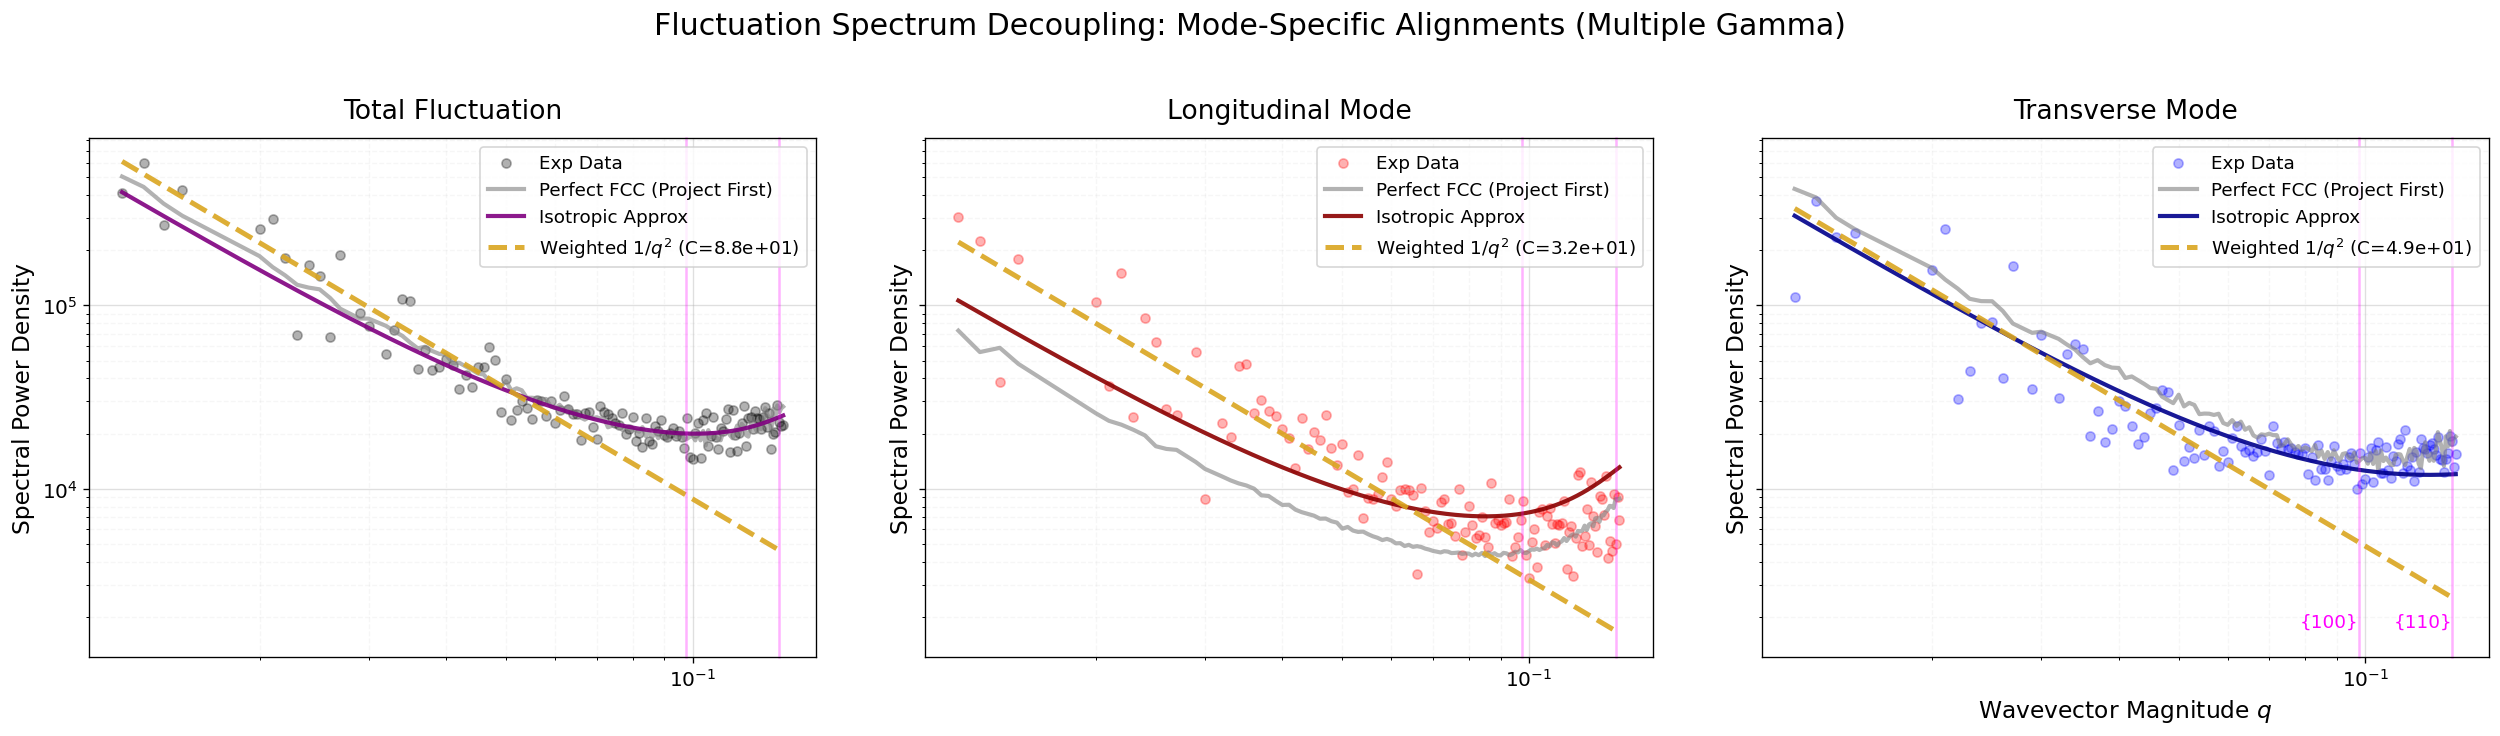


             GLOBAL PARAMETER EXTRACTION RESULTS                   
  [Global Isotropic Approximation - Multiple Gamma]
    Compressive Gamma (γ_L) : 2.7226e-05
    Shear Gamma (γ_T)       : 5.5579e-05
    Stiffness Anisotropy   : 0.49x
    Baseline Noise (C_tot) : 5.4359e+03

  [Perfect FCC Matrix (Project-then-Invert)]
    Scaling Amplitude (A)  : 2.4234e+04
    Baseline Noise (C_tot) : 2.6454e+03

  [Weighted 1/q² Fitting (Pole Constant C)]
    Total (C_tot)          : 8.7969e+01
    Longitudinal (C_L)     : 3.1943e+01
    Transverse (C_T)       : 4.8689e+01


In [9]:
# --- Ultimate 3x1 Combined Cell: Decoupled Gammas + Custom 1/q^2 Fit (FIXED) ---

# ==========================================
# 0. CONFIGURATION
# ==========================================
kb_T = 1.0 
SHELL_DECIMALS = 3
Q_MIN_CUTOFF = 0.005
Q_MAX_CUTOFF = 0.141

try:
    a_theo = EXPECTED_D_NN * np.sqrt(2.0)
except NameError:
    EXPECTED_D_NN = 25.0
    a_theo = EXPECTED_D_NN * np.sqrt(2.0)

# ==========================================
# 1. Perfect FCC Spectra Builder (Project Then Invert)
# ==========================================
def build_dynamical_spectra_project_first(g_down, g_up, Q_cov):
    NN_list = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, -1, 0], [0, 1, -1], [1, 0, -1]])
    M_tensors = np.zeros((6, 3, 3))
    for idx, n in enumerate(NN_list):
        R_cov = g_down @ n
        R_sq = n.T @ g_down @ n
        M_tensors[idx] = np.outer(R_cov, R_cov) / R_sq

    N_q = len(Q_cov)
    D_ij = np.zeros((N_q, 3, 3))
    for idx, n in enumerate(NN_list):
        phase = np.einsum('ni, i -> n', Q_cov, n)
        D_ij += 2.0 * (1.0 - np.cos(phase))[:, np.newaxis, np.newaxis] * M_tensors[idx]

    D_ij += 1e-8 * g_down[np.newaxis, :, :]

    Q_mag_sq = np.einsum('ij, ni, nj -> n', g_up, Q_cov, Q_cov)
    Q_mag = np.sqrt(np.maximum(Q_mag_sq, 1e-15))

    q_hat_cov = Q_cov / Q_mag[:, np.newaxis]
    q_hat_con = np.einsum('ij, nj -> ni', g_up, q_hat_cov)

    D_L_scalar = np.einsum('ni, nij, nj -> n', q_hat_con, D_ij, q_hat_con)
    D_trace = np.einsum('nij, ij -> n', D_ij, g_up)
    D_T_scalar = (D_trace - D_L_scalar) / 2.0

    S_L = 1.0 / np.maximum(D_L_scalar, 1e-15)
    S_T_single = 1.0 / np.maximum(D_T_scalar, 1e-15)
    S_T_sum = 2.0 * S_T_single
    S_tot = S_L + S_T_sum

    return S_tot, S_L, S_T_sum, Q_mag

print("Constructing Perfect FCC Matrix (Project then Invert)...")

# Define A_theo unconditionally — it only depends on a_theo, not on Q_highres,
# so it should never be tangled up with whether Q_highres exists.
A_theo = (a_theo / 2.0) * np.array([[0, 1, 1], [1, 0, 1], [1, 1, 0]])

# Only fall back if Q_highres genuinely doesn't exist — never overwrite a real one.
try:
    Q_highres
except NameError:
    print("Q_highres not found — generating a fallback grid.")
    Q_highres = np.random.rand(100, 3)

Q_vecs_cov_ideal = (A_theo.T @ Q_highres.T).T

g_ij_ideal = A_theo.T @ A_theo
g_up_ij_ideal = np.linalg.inv(g_ij_ideal)
S_tot_id, S_L_id, S_T_id, Q_mag_id = build_dynamical_spectra_project_first(g_ij_ideal, g_up_ij_ideal, Q_vecs_cov_ideal)

# ==========================================
# 2. Shell Smoothing Pipeline (FIXED: no merge — single position-aligned DataFrame)
# ==========================================
# Real and ideal arrays come from the SAME Q_highres grid points (same row order),
# so combine them by position instead of binning each separately and joining on
# a rounded q value (that join is what was producing 0 rows).
try:
    df_raw = pd.DataFrame({
        'q': Q_mag, 'S_tot_data': S_Total, 'S_L': S_L, 'S_T': S_T,
        'S_tot_id': S_tot_id, 'S_L_id': S_L_id, 'S_T_id': S_T_id
    }).sort_values('q').reset_index(drop=True)
except NameError:
    df_raw = pd.DataFrame({
        'q': Q_mag_id, 'S_tot_data': S_tot_id, 'S_L': S_L_id, 'S_T': S_T_id,
        'S_tot_id': S_tot_id, 'S_L_id': S_L_id, 'S_T_id': S_T_id
    }).sort_values('q').reset_index(drop=True)

def apply_shell_smoothing(df):
    df_temp = df.copy()
    df_temp['q_bin'] = np.round(df_temp['q'], SHELL_DECIMALS)
    res = df_temp.groupby('q_bin').mean().reset_index()
    return res.drop(columns=['q']).rename(columns={'q_bin': 'q'})

df_shells = apply_shell_smoothing(df_raw)
df_shells = df_shells[(df_shells['q'] > Q_MIN_CUTOFF) & (df_shells['q'] < Q_MAX_CUTOFF)].reset_index(drop=True)

print(f"df_shells rows after binning + cutoff: {len(df_shells)}")  # sanity check

# ==========================================
# 3. Decoupled Isotropic Math & Global Fits
# ==========================================
print("Executing Global Alignments...")

def isotropic_integrals(x):
    x_safe = np.maximum(x, 1e-8)
    I0, I2 = np.sin(x_safe) / x_safe, ((x_safe**2) * np.sin(x_safe) + 2 * x_safe * np.cos(x_safe) - 2 * np.sin(x_safe)) / (x_safe**3)
    small_x = x < 1e-4
    if isinstance(x, np.ndarray):
        I0[small_x] = 1.0 - (x[small_x]**2)/6.0
        I2[small_x] = 1.0/3.0 - (x[small_x]**2)/10.0
    return I0, I2

def compute_decoupled_isotropic(q_array, gamma_L, gamma_T, C_tot):
    I0, I2 = isotropic_integrals(q_array * EXPECTED_D_NN)
    D_L = np.maximum(gamma_L * (4.0 - 12.0 * I2), 1e-12)
    D_T_single = np.maximum(gamma_T * (4.0 - 6.0 * I0 + 6.0 * I2), 1e-12)
    C_mode = C_tot / 3.0
    S_L_theo = (kb_T / D_L) + C_mode
    S_T_theo_sum = 2.0 * ((kb_T / D_T_single) + C_mode)
    S_tot_theo = S_L_theo + S_T_theo_sum
    return S_tot_theo, S_L_theo, S_T_theo_sum

mask_fit = (df_shells['q'].values > 0.01) & (df_shells['S_tot_data'].values > 0.01)
print(f"mask_fit True count: {mask_fit.sum()}")  # sanity check

q_fit_joint = np.concatenate([df_shells['q'].values[mask_fit], df_shells['q'].values[mask_fit]])
y_fit_joint = np.concatenate([df_shells['S_L'].values[mask_fit], df_shells['S_T'].values[mask_fit]])

def log_model_joint_decoupled(q_dummy_joint, gamma_L, gamma_T, C_tot):
    N = len(q_dummy_joint) // 2
    q_vals = q_dummy_joint[:N]
    _, S_L, S_T = compute_decoupled_isotropic(q_vals, gamma_L, gamma_T, C_tot)
    return np.log10(np.concatenate([np.maximum(S_L, 1e-15), np.maximum(S_T, 1e-15)]))

# FIXED: wrap in try/except like Cell 6a does, so a bad fit doesn't kill the cell
try:
    popt_iso, _ = curve_fit(
        log_model_joint_decoupled, q_fit_joint, np.log10(y_fit_joint),
        p0=[1e-4, 1e-4, np.min(df_shells['S_tot_data'])],
        bounds=([1e-12, 1e-12, -np.inf], [np.inf, np.inf, np.inf])
    )
except Exception as e:
    print(f"Joint isotropic fit failed: {e}")
    popt_iso = [1e-4, 1e-4, 0.0]

def log_model_ideal(theory_x, A, C): return np.log10(np.maximum(A * theory_x + C, 1e-15))
try:
    popt_ideal, _ = curve_fit(
        log_model_ideal, df_shells['S_tot_id'].values[mask_fit], np.log10(df_shells['S_tot_data'].values[mask_fit]),
        p0=[np.median(df_shells['S_tot_data'][mask_fit]) / np.median(df_shells['S_tot_id'].values[mask_fit]), np.min(df_shells['S_tot_data'][mask_fit])],
        bounds=([0, -np.inf], [np.inf, np.inf])
    )
except Exception as e:
    print(f"FCC scaling fit failed: {e}")
    popt_ideal = [1.0, 0.0]

# --- 1/q^2 DEFINITIONS (unchanged) ---
def math_1_over_q2_model(q, C): return C / (q**2)
def log_model_q2_fit(lq, lC):
    q, C = 10**lq, 10**lC
    return np.log10(np.clip(math_1_over_q2_model(q, C), 1e-8, np.inf))

# ==========================================
# 4. Visualization (1x3 Grid) — unchanged from here on
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)

q_data = df_shells['q'].values
q_bound_smooth = np.logspace(np.log10(q_data.min()), np.log10(q_data.max()), 500)

S_tot_iso, S_L_iso, S_T_iso = compute_decoupled_isotropic(q_bound_smooth, *popt_iso)

row_configs = [
    (0, 'Total Fluctuation', df_shells['S_tot_data'].values, df_shells['S_tot_id'].values, S_tot_iso, 'black', 'purple'),
    (1, 'Longitudinal Mode', df_shells['S_L'].values, df_shells['S_L_id'].values, S_L_iso, 'red', 'darkred'),
    (2, 'Transverse Mode', df_shells['S_T'].values, df_shells['S_T_id'].values, S_T_iso, 'blue', 'darkblue')
]

q2_results = []

for row_idx, mode_name, y_data, S_id_data, S_iso_smooth, c_data, c_iso in row_configs:
    ax = axes[row_idx]

    mask_q2 = (q_data > 0.01) & (y_data > 0.01)
    q_fit = q_data[mask_q2]
    y_fit = y_data[mask_q2]
    guess_C = y_fit[0] * (q_fit[0]**2) if len(y_fit) > 0 else 1e-5

    try:
        popt_cont, _ = curve_fit(
            log_model_q2_fit, np.log10(q_fit), np.log10(y_fit),
            p0=[np.log10(guess_C)], sigma=q_fit, absolute_sigma=False, maxfev=10000
        )
        C_cont = 10**popt_cont[0]
    except Exception:
        C_cont = guess_C

    q2_results.append(C_cont)
    S_q2_smooth = math_1_over_q2_model(q_bound_smooth, C_cont)

    ax.scatter(q_data, y_data, color=c_data, alpha=0.3, s=30, label=f'Exp Data')

    noise_floor = popt_ideal[1] if row_idx == 0 else (popt_ideal[1] / 3.0 if row_idx == 1 else 2.0 * popt_ideal[1] / 3.0)
    ax.plot(q_data, popt_ideal[0] * S_id_data + noise_floor, color='grey', linestyle='-', lw=2.5, alpha=0.6, label=f'Perfect FCC (Project First)')

    ax.plot(q_bound_smooth, S_iso_smooth, color=c_iso, linestyle='-', lw=2.5, alpha=0.9, label=f'Isotropic Approx')

    ax.plot(q_bound_smooth, S_q2_smooth, color='goldenrod', linestyle='--', lw=3, alpha=0.9, label=f'Weighted $1/q^2$ (C={C_cont:.1e})')

    fcc_peaks = [{'label': '{100}', 'hkl_sq': 1}, {'label': '{110}', 'hkl_sq': 2}, {'label': '{111}', 'hkl_sq': 3}]
    trans = ax.get_xaxis_transform()
    for peak in fcc_peaks:
        q_p = (2.0 * np.pi / a_theo) * np.sqrt(peak['hkl_sq'])
        if q_p < Q_MAX_CUTOFF * 1.1:
            ax.plot([q_p, q_p], [0, 1], color='magenta', lw=1.5, alpha=0.3, transform=trans, clip_on=False)
            if row_idx == 2: ax.text(q_p, 0.05, peak['label'], color='magenta', transform=trans, ha='right', va='bottom', fontsize=11)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.1, linestyle='--')
    ax.legend(loc='upper right', fontsize=11, ncol=1)

    ax.set_ylabel('Spectral Power Density', fontsize=14)
    ax.set_title(mode_name, fontsize=16, pad=12)
    if row_idx == 2: ax.set_xlabel('Wavevector Magnitude $q$', fontsize=14)

plt.suptitle('Fluctuation Spectrum Decoupling: Mode-Specific Alignments (Multiple Gamma)', fontsize=18, y=1.02)
plt.tight_layout()
plt.subplots_adjust(wspace=0.15)

plt.savefig("Mode-Specific Alignments - Multiple Gamma.svg", format="svg", bbox_inches="tight")
plt.show()

# ==========================================
# 5. Extraction Output — unchanged
# ==========================================
print("\n===================================================================")
print("             GLOBAL PARAMETER EXTRACTION RESULTS                   ")
print("===================================================================")
print(f"  [Global Isotropic Approximation - Multiple Gamma]")
print(f"    Compressive Gamma (\u03B3_L) : {popt_iso[0]:.4e}")
print(f"    Shear Gamma (\u03B3_T)       : {popt_iso[1]:.4e}")
print(f"    Stiffness Anisotropy   : {popt_iso[0]/popt_iso[1]:.2f}x")
print(f"    Baseline Noise (C_tot) : {popt_iso[2]:.4e}\n")
print(f"  [Perfect FCC Matrix (Project-then-Invert)]")
print(f"    Scaling Amplitude (A)  : {popt_ideal[0]:.4e}")
print(f"    Baseline Noise (C_tot) : {popt_ideal[1]:.4e}\n")
print(f"  [Weighted 1/q² Fitting (Pole Constant C)]")
print(f"    Total (C_tot)          : {q2_results[0]:.4e}")
print(f"    Longitudinal (C_L)     : {q2_results[1]:.4e}")
print(f"    Transverse (C_T)       : {q2_results[2]:.4e}")
print("===================================================================")

Constructing Perfect FCC Matrix (Project then Invert)...
Executing Global Alignments on Total Fluctuation Data...


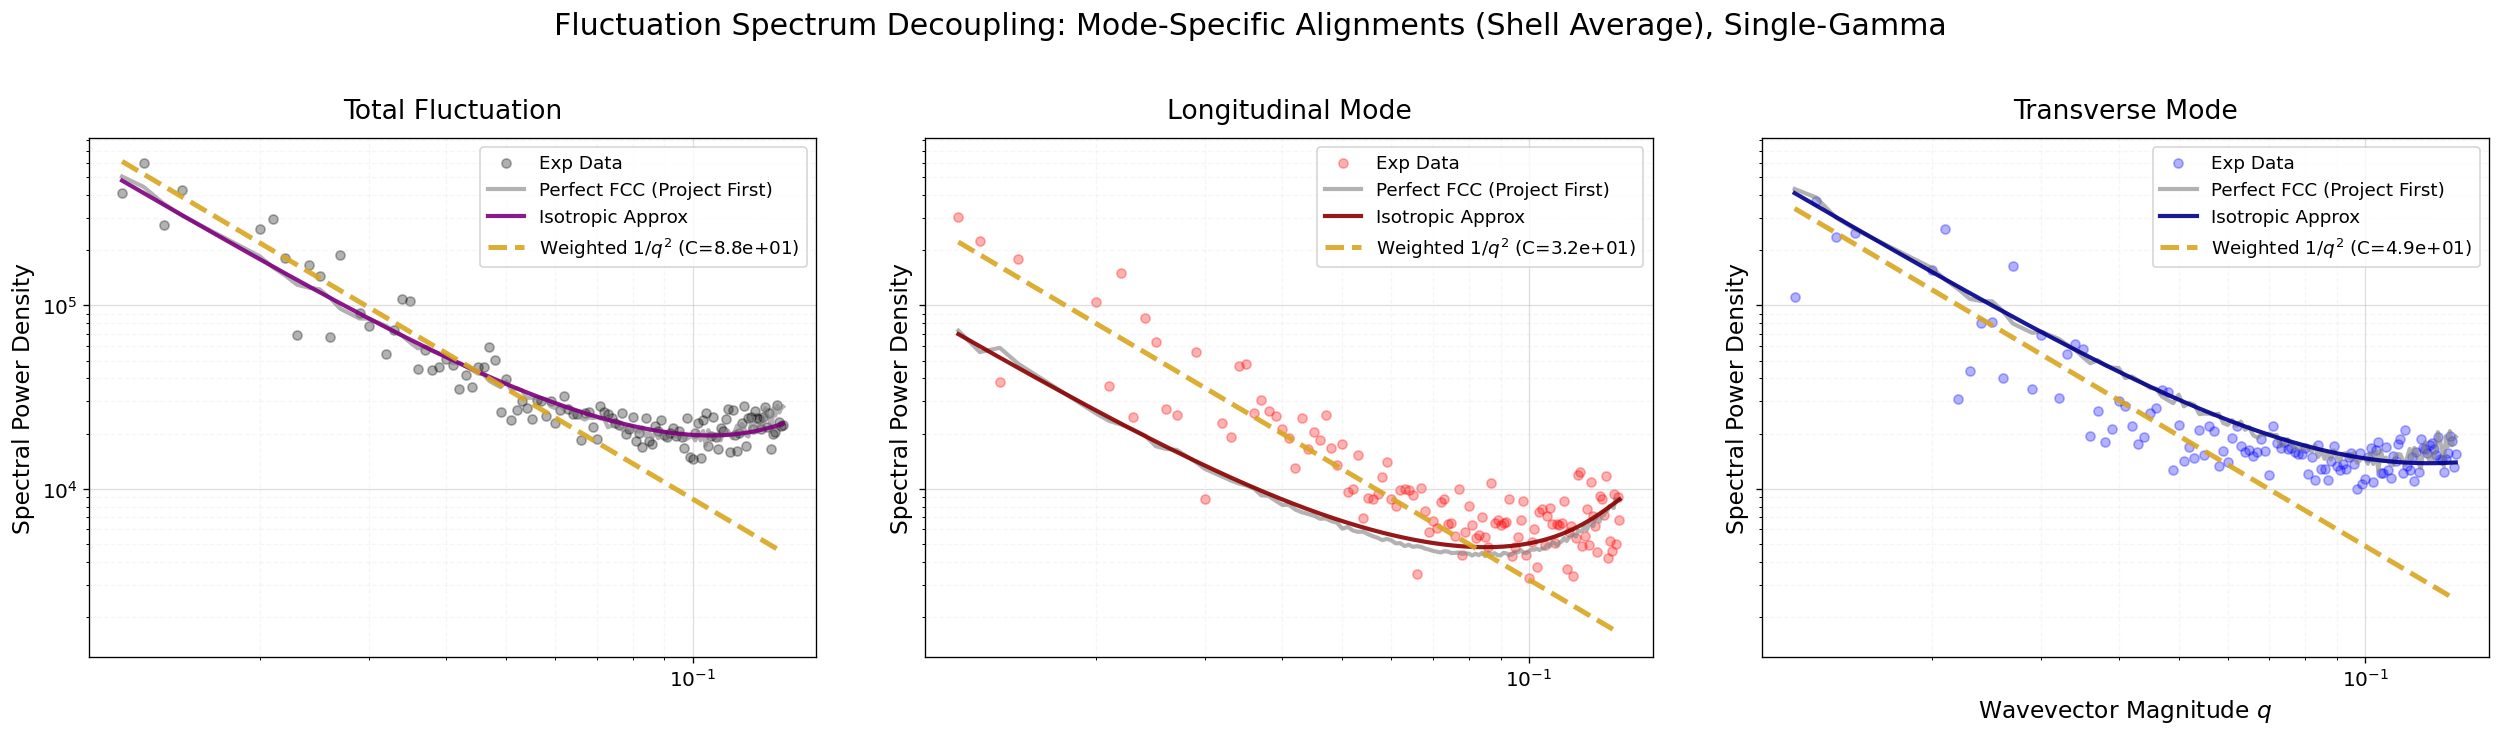


             GLOBAL PARAMETER EXTRACTION RESULTS                   
  [Global Isotropic Approximation - Single Gamma]
    Global Bond Gamma (γ_bond) : 4.1592e-05
    Baseline Noise (C_tot)     : 4.0724e+03

  [Perfect FCC Matrix (Project-then-Invert)]
    Scaling Amplitude (A)      : 2.4234e+04
    Baseline Noise (C_tot)     : 2.6454e+03

  [Weighted 1/q² Fitting (Pole Constant C)]
    Total (C_tot)              : 8.7969e+01
    Longitudinal (C_L)         : 3.1943e+01
    Transverse (C_T)           : 4.8689e+01


In [10]:
# --- Ultimate 3x1 Combined Cell: Final Physical Models + Restored 1/q^2 Fit ---

# ==========================================
# 0. CONFIGURATION
# ==========================================
kb_T = 1.0 
SHELL_DECIMALS = 3
Q_MIN_CUTOFF = 0.005
Q_MAX_CUTOFF = 0.141

try:
    a_theo = EXPECTED_D_NN * np.sqrt(2.0)
except NameError:
    EXPECTED_D_NN = 25.0 
    a_theo = EXPECTED_D_NN * np.sqrt(2.0)

# ==========================================
# 1. Perfect FCC Spectra Builder (Project Then Invert)
# ==========================================
def build_dynamical_spectra_project_first(g_down, g_up, Q_cov):
    """ Matches Analytical Derivation (Project to scalars, then invert) """
    NN_list = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, -1, 0], [0, 1, -1], [1, 0, -1]])
    M_tensors = np.zeros((6, 3, 3))
    for idx, n in enumerate(NN_list):
        R_cov = g_down @ n                 
        R_sq = n.T @ g_down @ n            
        M_tensors[idx] = np.outer(R_cov, R_cov) / R_sq
        
    N_q = len(Q_cov)
    D_ij = np.zeros((N_q, 3, 3))
    for idx, n in enumerate(NN_list):
        phase = np.einsum('ni, i -> n', Q_cov, n)
        D_ij += 2.0 * (1.0 - np.cos(phase))[:, np.newaxis, np.newaxis] * M_tensors[idx]
        
    D_ij += 1e-8 * g_down[np.newaxis, :, :] 
    
    Q_mag_sq = np.einsum('ij, ni, nj -> n', g_up, Q_cov, Q_cov)
    Q_mag = np.sqrt(np.maximum(Q_mag_sq, 1e-15))
    
    q_hat_cov = Q_cov / Q_mag[:, np.newaxis]
    q_hat_con = np.einsum('ij, nj -> ni', g_up, q_hat_cov)
    
    D_L_scalar = np.einsum('ni, nij, nj -> n', q_hat_con, D_ij, q_hat_con)
    D_trace = np.einsum('nij, ij -> n', D_ij, g_up)
    D_T_scalar = (D_trace - D_L_scalar) / 2.0
    
    S_L = 1.0 / np.maximum(D_L_scalar, 1e-15)
    S_T_single = 1.0 / np.maximum(D_T_scalar, 1e-15)
    S_T_sum = 2.0 * S_T_single
    S_tot = S_L + S_T_sum
    
    return S_tot, S_L, S_T_sum, Q_mag

print("Constructing Perfect FCC Matrix (Project then Invert)...")
try:
    Q_vecs_cov_ideal = (A_theo.T @ Q_highres.T).T 
except NameError:
    Q_highres = np.random.rand(100, 3) 
    A_theo = (a_theo / 2.0) * np.array([[0, 1, 1], [1, 0, 1], [1, 1, 0]])
    Q_vecs_cov_ideal = (A_theo.T @ Q_highres.T).T 

g_ij_ideal = A_theo.T @ A_theo
g_up_ij_ideal = np.linalg.inv(g_ij_ideal)
S_tot_id, S_L_id, S_T_id, Q_mag_id = build_dynamical_spectra_project_first(g_ij_ideal, g_up_ij_ideal, Q_vecs_cov_ideal)

# ==========================================
# 2. Shell Smoothing Pipeline
# ==========================================
try:
    df_raw_data = pd.DataFrame({'q': Q_mag, 'S_tot_data': S_Total, 'S_L': S_L, 'S_T': S_T}).sort_values('q').reset_index(drop=True)
except NameError:
    df_raw_data = pd.DataFrame({'q': Q_mag_id, 'S_tot_data': S_tot_id, 'S_L': S_L_id, 'S_T': S_T_id}).sort_values('q').reset_index(drop=True)

df_raw_id = pd.DataFrame({'q': Q_mag_id, 'S_tot_id': S_tot_id, 'S_L_id': S_L_id, 'S_T_id': S_T_id}).sort_values('q').reset_index(drop=True)

def apply_shell_smoothing(df):
    df_temp = df.copy()
    df_temp['q_bin'] = np.round(df_temp['q'], SHELL_DECIMALS)
    res = df_temp.groupby('q_bin').mean().reset_index()
    return res.drop(columns=['q']).rename(columns={'q_bin': 'q'})

df_shells = pd.merge(apply_shell_smoothing(df_raw_data), apply_shell_smoothing(df_raw_id), on='q', how='inner')
df_shells = df_shells[(df_shells['q'] > Q_MIN_CUTOFF) & (df_shells['q'] < Q_MAX_CUTOFF)].reset_index(drop=True)

# ==========================================
# 3. Corrected Isotropic Math & Global Fits
# ==========================================
print("Executing Global Alignments on Total Fluctuation Data...")

def isotropic_integrals(x):
    x_safe = np.maximum(x, 1e-8)
    I0, I2 = np.sin(x_safe) / x_safe, ((x_safe**2) * np.sin(x_safe) + 2 * x_safe * np.cos(x_safe) - 2 * np.sin(x_safe)) / (x_safe**3)
    small_x = x < 1e-4
    if isinstance(x, np.ndarray):
        I0[small_x] = 1.0 - (x[small_x]**2)/6.0
        I2[small_x] = 1.0/3.0 - (x[small_x]**2)/10.0
    return I0, I2

def compute_single_gamma(q_array, gamma_bond, C_tot):
    I0, I2 = isotropic_integrals(q_array * EXPECTED_D_NN)
    
    D_L = np.maximum(gamma_bond * (4.0 - 12.0 * I2), 1e-12)
    D_T_single = np.maximum(gamma_bond * (4.0 - 6.0 * I0 + 6.0 * I2), 1e-12)
    
    C_mode = C_tot / 3.0
    S_L_theo = (kb_T / D_L) + C_mode
    S_T_theo_sum = 2.0 * ((kb_T / D_T_single) + C_mode)
    S_tot_theo = S_L_theo + S_T_theo_sum 
    
    return S_tot_theo, S_L_theo, S_T_theo_sum

def log_model_single(q_dummy, gamma_bond, C_tot):
    S_tot, _, _ = compute_single_gamma(q_dummy, gamma_bond, C_tot)
    return np.log10(np.maximum(S_tot, 1e-15))

popt_iso, _ = curve_fit(
    log_model_single, df_shells['q'].values, np.log10(df_shells['S_tot_data'].values),
    p0=[1e-4, np.min(df_shells['S_tot_data'])], bounds=([1e-12, -np.inf], [np.inf, np.inf])
)

def log_model_ideal(theory_x, A, C): return np.log10(np.maximum(A * theory_x + C, 1e-15))
mask_tot = (df_shells['q'].values > 0.01) & (df_shells['S_tot_data'].values > 0.01)

try:
    popt_ideal, _ = curve_fit(
        log_model_ideal, df_shells['S_tot_id'].values[mask_tot], np.log10(df_shells['S_tot_data'].values[mask_tot]),
        p0=[np.median(df_shells['S_tot_data'][mask_tot]) / np.median(df_shells['S_tot_id'].values[mask_tot]), np.min(df_shells['S_tot_data'][mask_tot])],
        bounds=([0, -np.inf], [np.inf, np.inf])
    )
except Exception: popt_ideal = [1.0, 0.0]

# --- RESTORED 1/q^2 DEFINITIONS ---
def math_1_over_q2_model(q, C): return C / (q**2)
def log_model_q2_fit(lq, lC):
    q, C = 10**lq, 10**lC
    return np.log10(np.clip(math_1_over_q2_model(q, C), 1e-8, np.inf))

# ==========================================
# 4. Visualization (1x3 Grid)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)

q_data = df_shells['q'].values
q_bound_smooth = np.logspace(np.log10(q_data.min()), np.log10(q_data.max()), 500)

S_tot_iso, S_L_iso, S_T_iso = compute_single_gamma(q_bound_smooth, *popt_iso)

row_configs = [
    (0, 'Total Fluctuation', df_shells['S_tot_data'].values, df_shells['S_tot_id'].values, S_tot_iso, 'black', 'purple'),
    (1, 'Longitudinal Mode', df_shells['S_L'].values, df_shells['S_L_id'].values, S_L_iso, 'red', 'darkred'),
    (2, 'Transverse Mode', df_shells['S_T'].values, df_shells['S_T_id'].values, S_T_iso, 'blue', 'darkblue')
]

q2_results = []

for row_idx, mode_name, y_data, S_id_data, S_iso_smooth, c_data, c_iso in row_configs:
    ax = axes[row_idx]
    
    # --- USER'S EXACT 1/q^2 FIT BLOCK ---
    mask_q2 = (q_data > 0.01) & (y_data > 0.01) 
    q_fit = q_data[mask_q2]
    y_fit = y_data[mask_q2]
    guess_C = y_fit[0] * (q_fit[0]**2) if len(y_fit) > 0 else 1e-5
    
    try:
        popt_cont, _ = curve_fit(
            log_model_q2_fit, np.log10(q_fit), np.log10(y_fit), 
            p0=[np.log10(guess_C)], sigma=q_fit, absolute_sigma=False, maxfev=10000
        )
        C_cont = 10**popt_cont[0]
    except Exception:
        C_cont = guess_C
        
    q2_results.append(C_cont)
    S_q2_smooth = math_1_over_q2_model(q_bound_smooth, C_cont)
    # ------------------------------------
    
    ax.scatter(q_data, y_data, color=c_data, alpha=0.3, s=30, label=f'Exp Data')
    
    # FCC Mode Scaled (Properly distributing C_tot to C_tot/3 for sub-modes)
    noise_floor = popt_ideal[1] if row_idx == 0 else (popt_ideal[1] / 3.0 if row_idx == 1 else 2.0 * popt_ideal[1] / 3.0)
    ax.plot(q_data, popt_ideal[0] * S_id_data + noise_floor, color='grey', linestyle='-', lw=2.5, alpha=0.6, label=f'Perfect FCC (Project First)')
    
    ax.plot(q_bound_smooth, S_iso_smooth, color=c_iso, linestyle='-', lw=2.5, alpha=0.9, label=f'Isotropic Approx')
    ax.plot(q_bound_smooth, S_q2_smooth, color='goldenrod', linestyle='--', lw=3, alpha=0.9, label=f'Weighted $1/q^2$ (C={C_cont:.1e})')


    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.1, linestyle='--')
    ax.legend(loc='upper right', fontsize=11, ncol=1)
    
    ax.set_ylabel('Spectral Power Density', fontsize=14)
    ax.set_title(mode_name, fontsize=16, pad=12)
    if row_idx == 2: ax.set_xlabel('Wavevector Magnitude $q$', fontsize=14)

plt.suptitle('Fluctuation Spectrum Decoupling: Mode-Specific Alignments (Shell Average), Single-Gamma', fontsize=18, y=1.02)
plt.tight_layout()
plt.subplots_adjust(wspace=0.15) 

plt.savefig("Mode-Specific Alignments - Single Gamma.svg", format="svg", bbox_inches="tight")
plt.show()

# ==========================================
# 5. Extraction Output
# ==========================================
print("\n===================================================================")
print("             GLOBAL PARAMETER EXTRACTION RESULTS                   ")
print("===================================================================")
print(f"  [Global Isotropic Approximation - Single Gamma]")
print(f"    Global Bond Gamma (\u03B3_bond) : {popt_iso[0]:.4e}")
print(f"    Baseline Noise (C_tot)     : {popt_iso[1]:.4e}\n")
print(f"  [Perfect FCC Matrix (Project-then-Invert)]")
print(f"    Scaling Amplitude (A)      : {popt_ideal[0]:.4e}")
print(f"    Baseline Noise (C_tot)     : {popt_ideal[1]:.4e}\n")
print(f"  [Weighted 1/q² Fitting (Pole Constant C)]")
print(f"    Total (C_tot)              : {q2_results[0]:.4e}")
print(f"    Longitudinal (C_L)         : {q2_results[1]:.4e}")
print(f"    Transverse (C_T)           : {q2_results[2]:.4e}")
print("===================================================================")